SPIM v0 simulation
==================

In [2]:
import copy

import numpy as np
import scipy
import matplotlib.pyplot as plt

import optiland.backend as be
from optiland.optic import Optic
from optiland.fileio import load_zemax_file
from optiland.analysis import SpotDiagram

# Illumination arm schematic & components

![title](illumination_path.png)


### Optical elements

- __Multimode fiber__: 50/125 μm, NA 0.2 (OM4 telecom multimode fiber)
- __Fiber collimator__: F8.0, D4.0 
- __Beam expander 1st lens__: F50 doublet (analogue of Thorlabs AC254-050-A)
- __Beam expander 2nd lens__: F100 doublet (analogue of Thorlabs AC254-100-A)

- __Cylindrical lens__: F75, Thorlabs LJ1703RM-A
- __Scan lens__: F30, Thorlabs AC254-030-A
- __Tube lens__: F50, Thorlabs AC254-050-A
- __Illumination objective__: F45 (analogue of 4X Olympus Plan Achromat Objective, 0.10 NA)

### Elements loading

In [3]:
lens_f30 = load_zemax_file('zemax/AC254-030-A-Zemax-ZMX.zmx')
lens_f45 = load_zemax_file('zemax/AC254-045-A-Zemax-ZMX.zmx')
lens_f50 = load_zemax_file('zemax/AC254-050-A-Zemax-ZMX.zmx')
lens_f100 = load_zemax_file('zemax/AC254-100-A-Zemax-ZMX.zmx')
lens_f75_cyl = load_zemax_file('zemax/LJ1703RM-A-Zemax-ZMX.zmx')


╒════╤═════════════════╤═══════════╤══════════╤═════════════╤════════════╤═════════╤═════════════════╕
│    │ Type            │ Comment   │   Radius │   Thickness │ Material   │   Conic │   Semi-aperture │
╞════╪═════════════════╪═══════════╪══════════╪═════════════╪════════════╪═════════╪═════════════════╡
│  0 │ Planar          │           │   inf    │    inf      │ Air        │       0 │       11.43     │
│  1 │ Stop - Standard │           │    20.89 │     12      │ N-BAF10    │       0 │       11.43     │
│  2 │ Standard        │           │   -16.73 │      2      │ N-SF6HT    │       0 │        8.79574  │
│  3 │ Standard        │           │   -79.8  │     21.6876 │ Air        │       0 │        8.46829  │
│  4 │ Planar          │           │   inf    │    nan      │ Air        │       0 │        0.205374 │
╘════╧═════════════════╧═══════════╧══════════╧═════════════╧════════════╧═════════╧═════════════════╛



(<Figure size 1000x400 with 1 Axes>, <Axes: xlabel='Z [mm]', ylabel='Y [mm]'>)

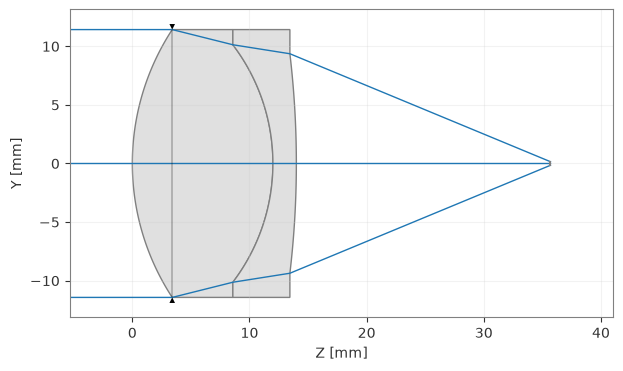

In [13]:
lens_f30.info()
lens_f30.draw()

### Custom aspheric fiber collimator lens

╒════╤═════════════════════╤═══════════╤═══════════╤═════════════╤════════════╤═══════════╤═════════════════╕
│    │ Type                │ Comment   │    Radius │   Thickness │ Material   │     Conic │   Semi-aperture │
╞════╪═════════════════════╪═══════════╪═══════════╪═════════════╪════════════╪═══════════╪═════════════════╡
│  0 │ Planar              │           │ inf       │   inf       │ Air        │  0        │         4       │
│  1 │ Stop - Even Asphere │           │   4.63812 │     3.434   │ D-ZK3      │ -0.925521 │         4       │
│  2 │ Planar              │           │ inf       │     5.79313 │ Air        │  0        │         2.90995 │
│  3 │ Planar              │           │ inf       │   nan       │ Air        │  0        │         0       │
╘════╧═════════════════════╧═══════════╧═══════════╧═════════════╧════════════╧═══════════╧═════════════════╛
╒═══════════╤══════╤══════════╤══════════╤═══════════╤════════════╤══════╤══════╤══════╕
│ Surface   │   c0 │       c1 │

/var/folders/_n/x6kt66zd1p1bt5_fbt2qnm6c0000gn/T/ipykernel_31885/240256627.py:4: DeprecationWarning: Optic.set_material is deprecated and will be removed in v0.7.0; use optic.updater.set_material() instead.
  lens_f8_as.set_material(material=MaterialCatalog("cdgm").get("D-ZK3"),
/var/folders/_n/x6kt66zd1p1bt5_fbt2qnm6c0000gn/T/ipykernel_31885/240256627.py:10: DeprecationWarning: Optic.update is deprecated and will be removed in v0.7.0; use optic.updater.update() instead.
  lens_f8_as.update()
/var/folders/_n/x6kt66zd1p1bt5_fbt2qnm6c0000gn/T/ipykernel_31885/240256627.py:11: DeprecationWarning: Optic.image_solve is deprecated and will be removed in v0.7.0; use optic.updater.image_solve() instead.
  lens_f8_as.image_solve()


(<Figure size 1000x400 with 1 Axes>, <Axes: xlabel='Z [mm]', ylabel='Y [mm]'>)

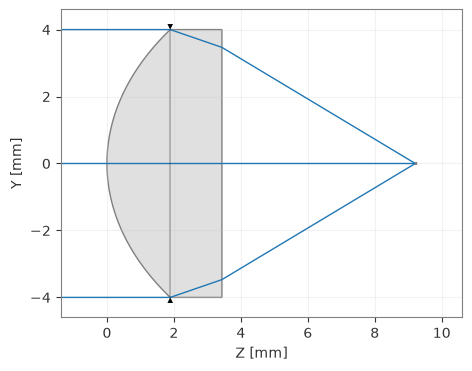

In [30]:
lens_f8_as = load_zemax_file('zemax/354240-Zemax-ZMX.zmx')

# lens_f8_as.info()
lens_f8_as.set_material(material=MaterialCatalog("cdgm").get("D-ZK3"),
                        surface_number=2)
lens_f8_as.surfaces.remove(1)
lens_f8_as.surfaces.remove(3)
lens_f8_as.surfaces.remove(3)

lens_f8_as.update()
lens_f8_as.image_solve()

lens_f8_as.info()
lens_f8_as.draw()

# Otical schematic simulation

### Fiber collimation

In [ ]:
fiber_na = 0.2  # OM4 numerical aperture
fiber_d = 50    # OM4 core diameter, micron
fiber_angle = fiber_na * 180 / np.pi  # paraxial estiamation of fiber output angle in degree

In [ ]:
lens = Optic()

lens.fields.set_type(field_type="angle")
lens.fields.add(y=0)

### Ligth sheet formation

In [ ]:
sd = SpotDiagram(element, num_rings=3)
print(sd.airy_disc_x_y(wavelength=520))

element.draw()


0.2 * 180 / np.pi

In [ ]:
type(element)

In [ ]:
element.updater.flip()
element.draw()

In [ ]:
elememt_2 = copy.deepcopy(element)

elememt_2.updater.flip()

element.draw()
elememt_2.draw()

In [ ]:


sd = SpotDiagram(lens_30)
sd.view()

In [ ]:
singlet = Optic()

# define surfaces
singlet.surfaces.add(index=0, radius=np.inf, thickness=np.inf)
singlet.surfaces.add(index=1, radius=20, thickness=5, is_stop=True, material="N-SF11")
singlet.surfaces.add(index=2, radius=np.inf, thickness=40)
singlet.surfaces.add(index=3)

# define aperture
singlet.set_aperture(aperture_type="EPD", value=25)

# define fields
singlet.fields.set_type(field_type="angle")
singlet.fields.add(y=0)

# define wavelengths
singlet.wavelengths.add(value=0.5, is_primary=True)

# draw it
singlet.draw(num_rays=10)

In [ ]:
class ProjectionLens210FOV(Optic):
    """A 210-degree FOV projection lens.

    Reference: Milton Laikin, Lens Design, 4th ed., CRC Press, 2007, Table 9.5.
    """

    def __init__(self):
        super().__init__()

        # Object surface (infinite distance)
        self.surfaces.add(index=0, radius=be.inf, thickness=be.inf)

        # Lens surfaces from Table 9.5
        self.surfaces.add(index=1, radius=21.1576, thickness=0.7000, material="N-K5")
        self.surfaces.add(index=2, radius=4.4088, thickness=1.6598)
        self.surfaces.add(index=3, radius=6.1240, thickness=0.6000, material="N-K5")
        self.surfaces.add(index=4, radius=2.6351, thickness=2.8079)
        self.surfaces.add(index=5, radius=-4.9887, thickness=0.6898, material="N-K5")
        self.surfaces.add(index=6, radius=-2.9312, thickness=0.4000, material="SF4")
        self.surfaces.add(index=7, radius=-3.0217, thickness=0.6229, material="N-PSK3")
        self.surfaces.add(index=8, radius=2.3857, thickness=0.8744)
        self.surfaces.add(index=9, radius=22.0209, thickness=0.7000, material="SF4")
        self.surfaces.add(index=10, radius=-8.2506, thickness=0.8566)
        self.surfaces.add(
            index=11, radius=101.6268, thickness=0.7000, material="N-SSK5"
        )
        self.surfaces.add(index=12, radius=-12.9224, thickness=0.4212)
        self.surfaces.add(index=13, radius=7.5022, thickness=0.5714, material="SF4")
        self.surfaces.add(index=14, radius=29.4757, thickness=0.2557)
        self.surfaces.add(index=15, radius=7.6940, thickness=0.4131, material="SF5")
        self.surfaces.add(index=16, radius=19.1201, thickness=0.5462)

        # Surface 17 is the Stop
        self.surfaces.add(index=17, radius=be.inf, thickness=0.1681, is_stop=True)

        self.surfaces.add(index=18, radius=-3.7912, thickness=0.2042, material="SF5")
        self.surfaces.add(index=19, radius=4.0170, thickness=0.2330, material="N-LAK7")
        self.surfaces.add(index=20, radius=-3.5074, thickness=0.0496)
        self.surfaces.add(index=21, radius=9.6933, thickness=0.6446, material="N-LAK7")
        self.surfaces.add(index=22, radius=-1.6179, thickness=0.2000, material="SF4")
        self.surfaces.add(index=23, radius=-6.4888, thickness=0.0150)
        self.surfaces.add(index=24, radius=3.5035, thickness=0.5518, material="N-LAK7")
        self.surfaces.add(index=25, radius=-68.3415, thickness=2.2162)

        # Image plane
        self.surfaces.add(index=26, radius=be.inf, thickness=0.0)

        # Aperture settings
        self.set_aperture("imageFNO", 2.0)

        # Field settings (0, 30, 60, 85, 105 degrees)
        self.fields.set_type("angle")
        self.fields.add(y=0.0)
        self.fields.add(y=30.0)
        self.fields.add(y=60.0)
        self.fields.add(y=85.0)

        # Wavelength settings (F, d, C lines in micrometers)
        self.wavelengths.add(value=0.4861)  # F line
        self.wavelengths.add(value=0.5876, is_primary=True)  # d line
        self.wavelengths.add(value=0.6563)  # C line

        self.ray_tracer.set_aiming("robust")

In [ ]:
lens = ProjectionLens210FOV()
_ = lens.draw()